In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px  # Interface haut niveau pour graphiques simples
import plotly.graph_objects as go  # Interface bas niveau pour contrôle précis
import seaborn as sns
from plotly.subplots import make_subplots  # Création de grilles de graphiques

#Affichage complet des colonnes et des lignes (pas de retour a la ligne)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.expand_frame_repr", False)

#Import du fichier csv customer
url = "./../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url,sep=",")

# Affichage des dimension du jeu de données
print(f"Le jeu de données a {df.shape[0]} lignes et {df.shape[1]} colonnes")

# Affichez les 5 premières lignes
print(df.head())
display(df.info())


Le jeu de données a 7043 lignes et 21 colonnes
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges Churn
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No          Yes               No          No          No              No  Month-to-month              Yes           Electronic check           29.85        29.85    No
1  5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes           No              Yes          No          No              No        One year               No               Mailed check           56.95       1889.5    No
2  3668-QPYBK    Male              0      No         No       2          Yes    

None

Séparation des datas

In [ ]:
from sklearn.model_selection import train_test_split
#tri des datas croissant
df = df.sort_values(by="tenure", ascending=True).reset_index(drop=True)
df_test_final= df[df["tenure"] == 0]
df= df[df["tenure"] != 0]

SEED = 42
# Séparez le jeu de données
df_train, df_test = train_test_split(df,test_size=0.2,random_state=SEED)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
11,1066-JKSGK,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
12,6260-ONULR,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,62.80,62.8,No
13,4786-UKSNZ,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.2,Yes
14,0082-LDZUE,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,44.30,44.3,No
15,0723-DRCLG,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.45,74.45,Yes


In [75]:

from sklearn.pipeline import make_pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import export_graphviz, plot_tree
import subprocess
import os
from IPython.display import Image, display
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer

# Initialisation de l'encodeur
le = LabelEncoder()

# Création de la matrice X de variables explicatives
X_train = df_train[[
     "InternetService", "tenure",
    "PaymentMethod", "MonthlyCharges", "TotalCharges"
]].copy()

X_train.columns = X_train.columns.str.strip()  # sécurité espaces cachés


# Création du vecteur y
y = le.fit_transform(df_train["Churn"].values)

Creation du pipeline

In [76]:

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = ["InternetService", "PaymentMethod"]

# tes fonctions doivent modifier X, pas df
def cast_str_num(X):
    X = X.copy()
    X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")
    return X

def fill_total_charge(X):
    X = X.copy()
    m = X["TotalCharges"].isna()
    X.loc[m, "TotalCharges"] = X.loc[m, "tenure"] * X.loc[m, "MonthlyCharges"]
    return X

num_pipe = make_pipeline(
    FunctionTransformer(cast_str_num, validate=False, feature_names_out="one-to-one"),
    FunctionTransformer(fill_total_charge, validate=False, feature_names_out="one-to-one"),
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

pipeline_class = make_pipeline(
    preprocessor,
    DecisionTreeClassifier(max_depth=7, random_state=42)
)
pipeline_class.fit(X_train, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [71]:
pipeline_class.steps[1][1]

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

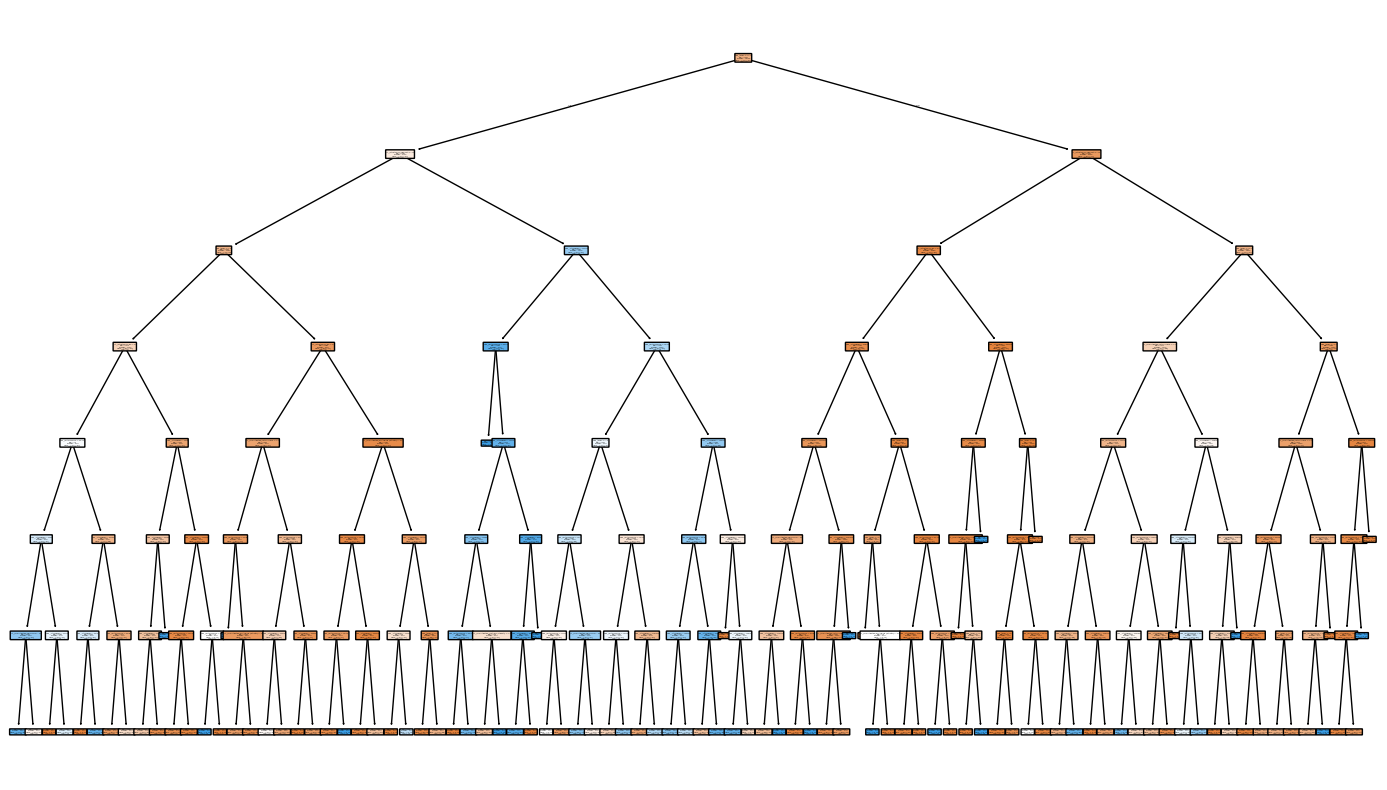

In [89]:
arbre_decision = pipeline_class.named_steps["decisiontreeclassifier"]
feature_names = pipeline_class.named_steps["columntransformer"].get_feature_names_out()

fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(
    arbre_decision,
    feature_names=feature_names,
    class_names=[str(c) for c in le.classes_],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    ax=ax
)
plt.tight_layout()
plt.show()

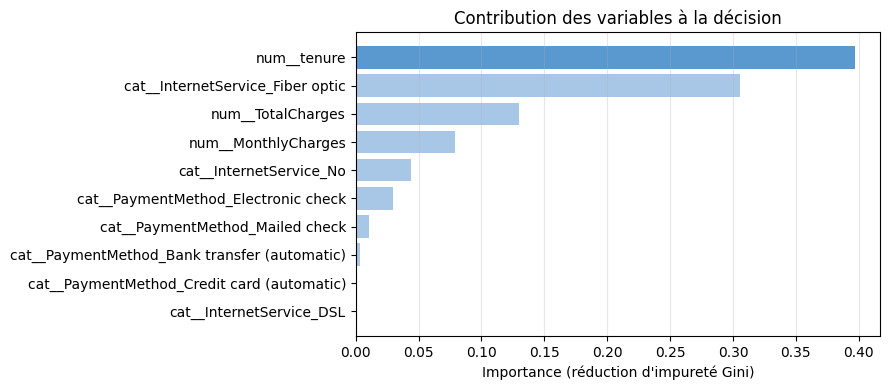


📊 Tableau des importances :


,caracteristique,importance
0,num__tenure,0.397060
4,cat__InternetService_Fiber optic,0.305239
2,num__TotalCharges,0.129872
1,num__MonthlyCharges,0.079274
5,cat__InternetService_No,0.043972
8,cat__PaymentMethod_Electronic check,0.029396
9,cat__PaymentMethod_Mailed check,0.010832
6,cat__PaymentMethod_Bank transfer (automatic),0.003406
7,cat__PaymentMethod_Credit card (automatic),0.000948
3,cat__InternetService_DSL,0.000000


In [90]:
# Calcul et visualisation des importances de caractéristiques
feature_names = pipeline_class.named_steps["columntransformer"].get_feature_names_out()
importances = pipeline_class.named_steps["decisiontreeclassifier"].feature_importances_

importances_caracteristiques = (
    pd.DataFrame({
        "caracteristique": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

# Visualisation
fig, ax = plt.subplots(figsize=(9, 4))
couleurs = ["#5a98d0" if i == 0 else "#a8c7e7" for i in range(len(importances_caracteristiques))]
ax.barh(importances_caracteristiques["caracteristique"],
        importances_caracteristiques["importance"],
        color=couleurs)
ax.invert_yaxis()
ax.set_xlabel("Importance (réduction d'impureté Gini)")
ax.set_title("Contribution des variables à la décision")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Tableau des importances :")
importances_caracteristiques

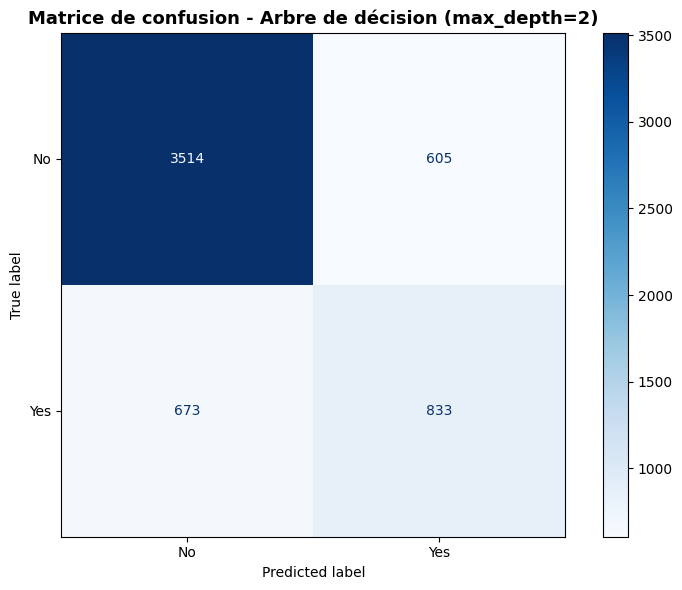

📈 Métriques de performance :
   • F1 Score (micro)    : 0.773
   • F1 Score (pondéré)  : 0.771

💡 Interprétation : Un score proche de 1 indique d'excellentes performances.


In [91]:
from sklearn.model_selection import cross_val_predict

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
# Prédictions par validation croisée (3 folds)
predictions_cv = cross_val_predict(pipeline_class, X_train, y, cv=3)

# Calcul de la matrice de confusion
matrice_confusion = confusion_matrix(y, predictions_cv)
affichage_matrice = ConfusionMatrixDisplay(
    confusion_matrix=matrice_confusion,
    display_labels=le.classes_
)

# Visualisation
fig, ax = plt.subplots(figsize=(8, 6))
affichage_matrice.plot(ax=ax, cmap="Blues", colorbar=True)
ax.set_title("Matrice de confusion - Arbre de décision (max_depth=2)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Calcul des métriques
score_f1_micro = f1_score(y, predictions_cv, average='micro')
score_f1_weighted = f1_score(y, predictions_cv, average='weighted')

print(f"📈 Métriques de performance :")
print(f"   • F1 Score (micro)    : {score_f1_micro:.3f}")
print(f"   • F1 Score (pondéré)  : {score_f1_weighted:.3f}")
print(f"\n💡 Interprétation : Un score proche de 1 indique d'excellentes performances.")